# BIST KAP Bildirimleri — Kural-Bazlı Sentiment Karşılaştırması

**Amaç:** `notebooks/03_sentiment.ipynb`'de savasy BERT'in finansal dil için yetersiz kaldığı (domain mismatch) tespit edilmişti. Bu notebook, KAP `subject` taksonomisine dayalı **deterministik bir sınıflandırma** ile aynı CAR sinyalini sınar ve iki yöntemi karşılaştırır.

**Yöntem:** `src/analysis/rule_sentiment.py` — 4 subject sabit POZ (kar payı, geri alım, yeni iş, varlık edinimi), 1 sabit NEG (varlık satışı), 3 subject keyword-bazlı (sermaye art/azalt, pay al/sat, kredi derecelendirme), 12 sabit NÖT.

**Anahtar sorular:**
1. Rule-based etiketler CAR'ı predict ediyor mu (BERT'ten daha iyi mi)?
2. Pozitif rule_label + ertesi-gün timing → en güçlü sinyal mi?
3. İki yöntem nerede ayrışıyor — disagreement'lar hangi bildirim türünde?


In [1]:
from __future__ import annotations
import sys
from pathlib import Path

_here = Path.cwd()
_project_root = _here if (_here / "src").exists() else _here.parent
if str(_project_root) not in sys.path:
    sys.path.insert(0, str(_project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from src.config import TICKERS, PROCESSED_DIR
from src.analysis.loaders import load_all_prices, load_all_disclosures
from src.analysis.event_study import run_event_study_multi

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 4)
pd.set_option("display.precision", 4)


## 1. Veri Hazırlığı

Sentiment.parquet hem BERT (`sentiment_label`) hem rule (`rule_label`) etiketlerini taşıyor. Event study'yi yeniden çalıştırıp birleştiriyoruz.

In [2]:
sentiment = pd.read_parquet(PROCESSED_DIR / "sentiment.parquet")
prices = load_all_prices()
news = load_all_disclosures()
results = run_event_study_multi(prices, news, before=1, after=3, estimation_window=60)
ok = results[results["status"] == "ok"].copy()

news_with_idx = news.reset_index().rename(columns={"index": "event_idx"})
ok = ok.merge(
    news_with_idx[["event_idx", "disclosure_index", "ticker", "subject", "summary"]],
    on=["event_idx", "ticker"], how="left", validate="one_to_one",
)
df = ok.merge(
    sentiment[["ticker", "disclosure_index", "sentiment_label", "sentiment_score", "rule_label"]],
    on=["ticker", "disclosure_index"], how="left",
)

df["event_date"] = pd.to_datetime(df["event_time"]).dt.date
df["mapped_date"] = pd.to_datetime(df["mapped_bar"]).dt.date
df["timing"] = np.where(df["event_date"] == df["mapped_date"], "ayni-gun", "ertesi-gun")

print(f"OK olay: {len(df)}")
print()
print("Rule label dagilim:")
print(df["rule_label"].value_counts().to_string())


OK olay: 221

Rule label dagilim:
rule_label
neutral     180
positive     28
negative     13


## 2. Rule Label × CAR — Temel İstatistik

Üç-kategori sınıflandırma (pos/neg/neut) için ortalama CAR ve t-test'ler.

In [3]:
print("CAR by rule_label:")
print(df.groupby("rule_label")["car"].describe().round(5))


CAR by rule_label:
            count    mean     std     min     25%     50%     75%     max
rule_label                                                               
negative     13.0  0.0035  0.0137 -0.0155 -0.0026  0.0060  0.0115  0.0297
neutral     180.0  0.0011  0.0185 -0.0630 -0.0108  0.0012  0.0154  0.0662
positive     28.0  0.0017  0.0204 -0.0525 -0.0145  0.0030  0.0175  0.0369


In [4]:
# Pos vs Neg Welch t-test (neutral haric)
pos = df[df["rule_label"] == "positive"]["car"].dropna()
neg = df[df["rule_label"] == "negative"]["car"].dropna()
neu = df[df["rule_label"] == "neutral"]["car"].dropna()

print(f"Positive: n={len(pos)}, ort CAR = {pos.mean()*100:+.3f}%, std = {pos.std()*100:.3f}%")
print(f"Negative: n={len(neg)}, ort CAR = {neg.mean()*100:+.3f}%, std = {neg.std()*100:.3f}%")
print(f"Neutral : n={len(neu)}, ort CAR = {neu.mean()*100:+.3f}%, std = {neu.std()*100:.3f}%")
print()
welch = stats.ttest_ind(pos, neg, equal_var=False)
print(f"Welch pos vs neg : t={welch.statistic:.3f}, p={welch.pvalue:.4f}")

# Tek-ornek t: pos CAR > 0?
t_pos = stats.ttest_1samp(pos, 0.0)
print(f"Pos vs 0 (1-samp): t={t_pos.statistic:.3f}, p={t_pos.pvalue:.4f}")

# Sign test pos > 0
n_p = (pos > 0).sum()
print(f"Pos sign test: {n_p}/{len(pos)}={n_p/len(pos):.1%} pozitif, "
      f"p={stats.binomtest(n_p, len(pos), p=0.5, alternative='two-sided').pvalue:.4f}")


Positive: n=28, ort CAR = +0.174%, std = 2.043%
Negative: n=13, ort CAR = +0.351%, std = 1.366%
Neutral : n=180, ort CAR = +0.113%, std = 1.853%

Welch pos vs neg : t=-0.328, p=0.7447
Pos vs 0 (1-samp): t=0.450, p=0.6562
Pos sign test: 16/28=57.1% pozitif, p=0.5716


C:\Users\csp\AppData\Local\Temp\ipykernel_35032\1055751497.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="rule_label", y="car_pct", order=order, palette=palette, ax=ax)


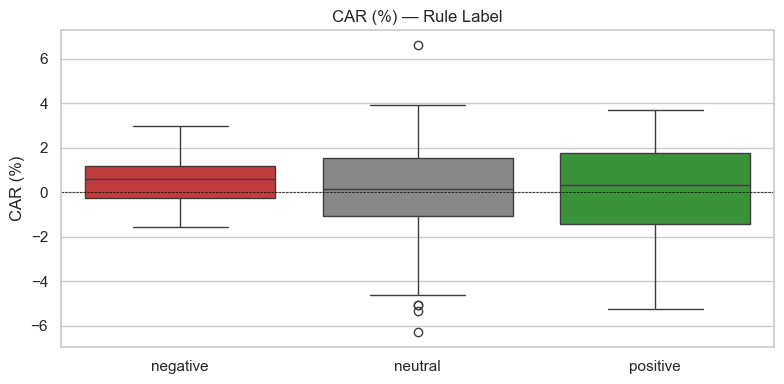

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_df = df.assign(car_pct=df["car"] * 100)
order = ["negative", "neutral", "positive"]
palette = {"negative": "#d62728", "neutral": "#888888", "positive": "#2ca02c"}
sns.boxplot(data=plot_df, x="rule_label", y="car_pct", order=order, palette=palette, ax=ax)
ax.axhline(0, color="black", linestyle="--", linewidth=0.5)
ax.set_title("CAR (%) — Rule Label")
ax.set_xlabel("")
ax.set_ylabel("CAR (%)")
plt.tight_layout()
plt.show()


## 3. Rule × Timing 2×3 Izgara

Hipotez: pozitif rule_label + ertesi-gun en yuksek CAR (event study'deki ertesi-gun sinyalinin sentiment ekseninde guclenmesi).

In [6]:
grid = df.groupby(["rule_label", "timing"])["car"].agg(["count", "mean", "std"])
grid["mean_pct"] = grid["mean"] * 100
grid["std_pct"] = grid["std"] * 100
print("Rule x Timing x CAR:")
print(grid[["count", "mean_pct", "std_pct"]].round(3).to_string())


Rule x Timing x CAR:
                       count  mean_pct  std_pct
rule_label timing                              
negative   ayni-gun        7    -0.260    1.273
           ertesi-gun      6     1.064    1.185
neutral    ayni-gun      128    -0.113    1.753
           ertesi-gun     52     0.671    1.988
positive   ayni-gun       18    -0.290    1.707
           ertesi-gun     10     1.009    2.412


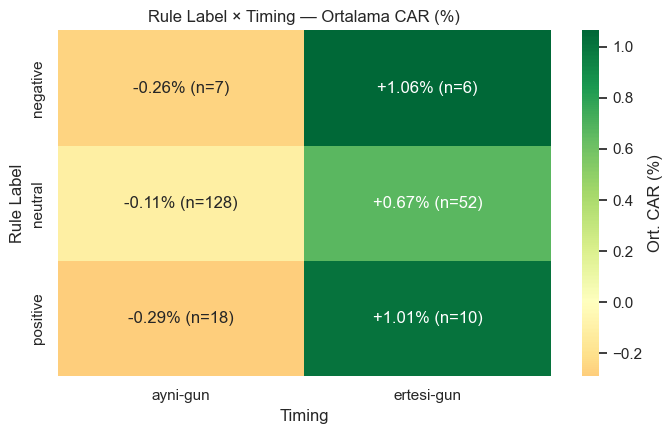

In [7]:
pivot_mean = df.assign(car_pct=df["car"] * 100).pivot_table(
    index="rule_label", columns="timing", values="car_pct", aggfunc="mean"
).reindex(["negative", "neutral", "positive"])
pivot_n = df.pivot_table(
    index="rule_label", columns="timing", values="car", aggfunc="count"
).reindex(["negative", "neutral", "positive"])

annot = pivot_mean.copy().astype(str)
for r in pivot_mean.index:
    for c in pivot_mean.columns:
        v = pivot_mean.loc[r, c]
        n = pivot_n.loc[r, c]
        if pd.isna(v):
            annot.loc[r, c] = "—"
        else:
            annot.loc[r, c] = f"{v:+.2f}% (n={int(n)})"

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.heatmap(pivot_mean, annot=annot, fmt="", cmap="RdYlGn", center=0,
            cbar_kws={"label": "Ort. CAR (%)"}, ax=ax)
ax.set_title("Rule Label × Timing — Ortalama CAR (%)")
ax.set_xlabel("Timing")
ax.set_ylabel("Rule Label")
plt.tight_layout()
plt.show()


In [8]:
# Anahtar test: pozitif × ertesi-gun
key = df[(df["rule_label"] == "positive") & (df["timing"] == "ertesi-gun")]["car"].dropna()
rest = df[~((df["rule_label"] == "positive") & (df["timing"] == "ertesi-gun"))]["car"].dropna()

print(f"Positive x Ertesi-gun (key):  n={len(key)}, ort CAR = {key.mean()*100:+.3f}%")
print(f"Geri kalan                  : n={len(rest)}, ort CAR = {rest.mean()*100:+.3f}%")
welch = stats.ttest_ind(key, rest, equal_var=False)
print(f"Welch t-test (key vs rest): t={welch.statistic:.3f}, p={welch.pvalue:.4f}")
one = stats.ttest_1samp(key, 0.0)
print(f"Tek-ornek t (key vs 0):    t={one.statistic:.3f}, p={one.pvalue:.4f}")
n_pos = (key > 0).sum()
print(f"Sign test: {n_pos}/{len(key)}={n_pos/len(key):.1%} pozitif, "
      f"p={stats.binomtest(n_pos, len(key), p=0.5, alternative='two-sided').pvalue:.4f}")


Positive x Ertesi-gun (key):  n=10, ort CAR = +1.009%
Geri kalan                  : n=211, ort CAR = +0.093%
Welch t-test (key vs rest): t=1.185, p=0.2648
Tek-ornek t (key vs 0):    t=1.323, p=0.2183
Sign test: 9/10=90.0% pozitif, p=0.0215


## 4. BERT vs Rule — Karşılaştırmalı Performans

Hangi sınıflandırma CAR sinyaline daha yakın? İki açıdan ölçüyoruz:
1. **Pos-Neg CAR farkı** (etiketin yönü ne kadar bilgilendirici)
2. **2-grup t-test p-değeri** (anlamlılık)

In [9]:
def evaluate(label_col: str) -> dict:
    pos = df[df[label_col] == "positive"]["car"].dropna()
    neg = df[df[label_col] == "negative"]["car"].dropna()
    if len(pos) == 0 or len(neg) == 0:
        return {"label_col": label_col, "n_pos": len(pos), "n_neg": len(neg)}
    diff = (pos.mean() - neg.mean()) * 100
    t = stats.ttest_ind(pos, neg, equal_var=False)
    return {
        "yontem": label_col,
        "n_pos": len(pos),
        "n_neg": len(neg),
        "pos_ort_car_pct": pos.mean() * 100,
        "neg_ort_car_pct": neg.mean() * 100,
        "pos_neg_diff_pct": diff,
        "welch_t": t.statistic,
        "welch_p": t.pvalue,
    }

rows = [evaluate("sentiment_label"), evaluate("rule_label")]
cmp = pd.DataFrame(rows).round(4)
print(cmp.to_string(index=False))


         yontem  n_pos  n_neg  pos_ort_car_pct  neg_ort_car_pct  pos_neg_diff_pct  welch_t  welch_p
sentiment_label    109    112          -0.0061           0.2721           -0.2782  -1.1191   0.2643
     rule_label     28     13           0.1738           0.3515           -0.1777  -0.3284   0.7447


In [10]:
# Cohen's kappa: iki yontem ne kadar anlasiyor?
from sklearn.metrics import cohen_kappa_score

# Iki yontemin paylasi'lan label uzayina map'le: positive/negative/neutral
# BERT: positive/negative -> bert_3way (neutral yok)
mask = df["sentiment_label"].isin(["positive", "negative"]) & df["rule_label"].notna()
sub = df[mask]
kappa = cohen_kappa_score(sub["sentiment_label"], sub["rule_label"])
print(f"Cohen's kappa (BERT vs Rule, n={len(sub)}): {kappa:.3f}")
print()
print("Cross-tab:")
print(pd.crosstab(sub["sentiment_label"], sub["rule_label"], margins=True))


Cohen's kappa (BERT vs Rule, n=221): -0.007

Cross-tab:
rule_label       negative  neutral  positive  All
sentiment_label                                  
negative                9       85        18  112
positive                4       95        10  109
All                    13      180        28  221


## 5. Disagreement Analizi — Iki Yontem Nerede Ayrisiyor?

BERT pos + Rule neg ve BERT neg + Rule pos kombinasyonlari: hangi bildirimler bu cellelere dusuyor?

In [11]:
# BERT pos + Rule neg
mask_bp_rn = (df["sentiment_label"] == "positive") & (df["rule_label"] == "negative")
print(f"=== BERT pos + Rule neg ({mask_bp_rn.sum()} olay) ===")
for _, r in df[mask_bp_rn].head(8).iterrows():
    print(f"  [{r['ticker']}] BERT_score={r['sentiment_score']:.2f} CAR={r['car']*100:+.2f}%  | {r['subject']}: {(r['summary'] or '')[:80]}")


=== BERT pos + Rule neg (4 olay) ===
  [KCHOL] BERT_score=0.60 CAR=+0.68%  | Sermaye Artırımı - Azaltımı İşlemlerine İlişkin Bildirim: Tahsisli Sermaye Artırımında Payların Satışının Tamamlanması Sonucunda Esas Sözl
  [KCHOL] BERT_score=0.94 CAR=+0.60%  | Pay Alım Satım Bildirimi: Hisse satışına ilişkin yetkilendirme ve satış sürecinin başlangıcı
  [KCHOL] BERT_score=0.59 CAR=+0.60%  | Pay Alım Satım Bildirimi: Hisse satış sürecinde işlem detaylarının belirlenmesi
  [KCHOL] BERT_score=0.88 CAR=+1.62%  | Pay Alım Satım Bildirimi: Pay satış işleminin tamamlanması


In [12]:
# BERT neg + Rule pos
mask_bn_rp = (df["sentiment_label"] == "negative") & (df["rule_label"] == "positive")
print(f"=== BERT neg + Rule pos ({mask_bn_rp.sum()} olay) ===")
for _, r in df[mask_bn_rp].head(8).iterrows():
    print(f"  [{r['ticker']}] BERT_score={r['sentiment_score']:.2f} CAR={r['car']*100:+.2f}%  | {r['subject']}: {(r['summary'] or '')[:80]}")


=== BERT neg + Rule pos (18 olay) ===
  [THYAO] BERT_score=0.57 CAR=-5.25%  | Payların Geri Alınmasına İlişkin Bildirim: 27.02.2026 Tarihli Hisse Geri Alım İşlemleri Hakkında Bildirim
  [THYAO] BERT_score=0.92 CAR=+0.93%  | Kar Payı Dağıtım İşlemlerine İlişkin Bildirim: 2025 Yılı Kâr Dağıtımı ile ilgili Genel Kurul Kararı
  [ASELS] BERT_score=0.98 CAR=-1.97%  | Finansal Duran Varlık Edinimi: Finansal Duran Varlık Edinimi
  [ASELS] BERT_score=0.98 CAR=-1.97%  | Finansal Duran Varlık Edinimi: Finansal Duran Varlık Edinimi
  [ASELS] BERT_score=0.98 CAR=-0.40%  | Kar Payı Dağıtım İşlemlerine İlişkin Bildirim: Kâr Payı Dağıtımı
  [ASELS] BERT_score=0.98 CAR=+2.46%  | Kar Payı Dağıtım İşlemlerine İlişkin Bildirim: Kâr Payı Dağıtım
  [GARAN] BERT_score=0.97 CAR=+3.27%  | Kar Payı Dağıtım İşlemlerine İlişkin Bildirim: 2025 Yılı Kar Dağıtımına İlişkin Yönetim Kurulu Kararı Hk.
  [GARAN] BERT_score=1.00 CAR=+1.74%  | Kar Payı Dağıtım İşlemlerine İlişkin Bildirim: 2025 Yılı Kar Dağıtımı Hk.



## 6. Ozet Bulgular (run sonrası README'ye taşınacak)